## 7.1 Modelo Estrella — Diagrama Multimodal (4 Dimensiones)

Este diseño separa las fuentes de datos en 4 dimensiones clave para permitir un análisis granular del impacto climático y social en la producción de limón.

### Vista Conceptual (Esquema de la Tesis)
<div align="center">
    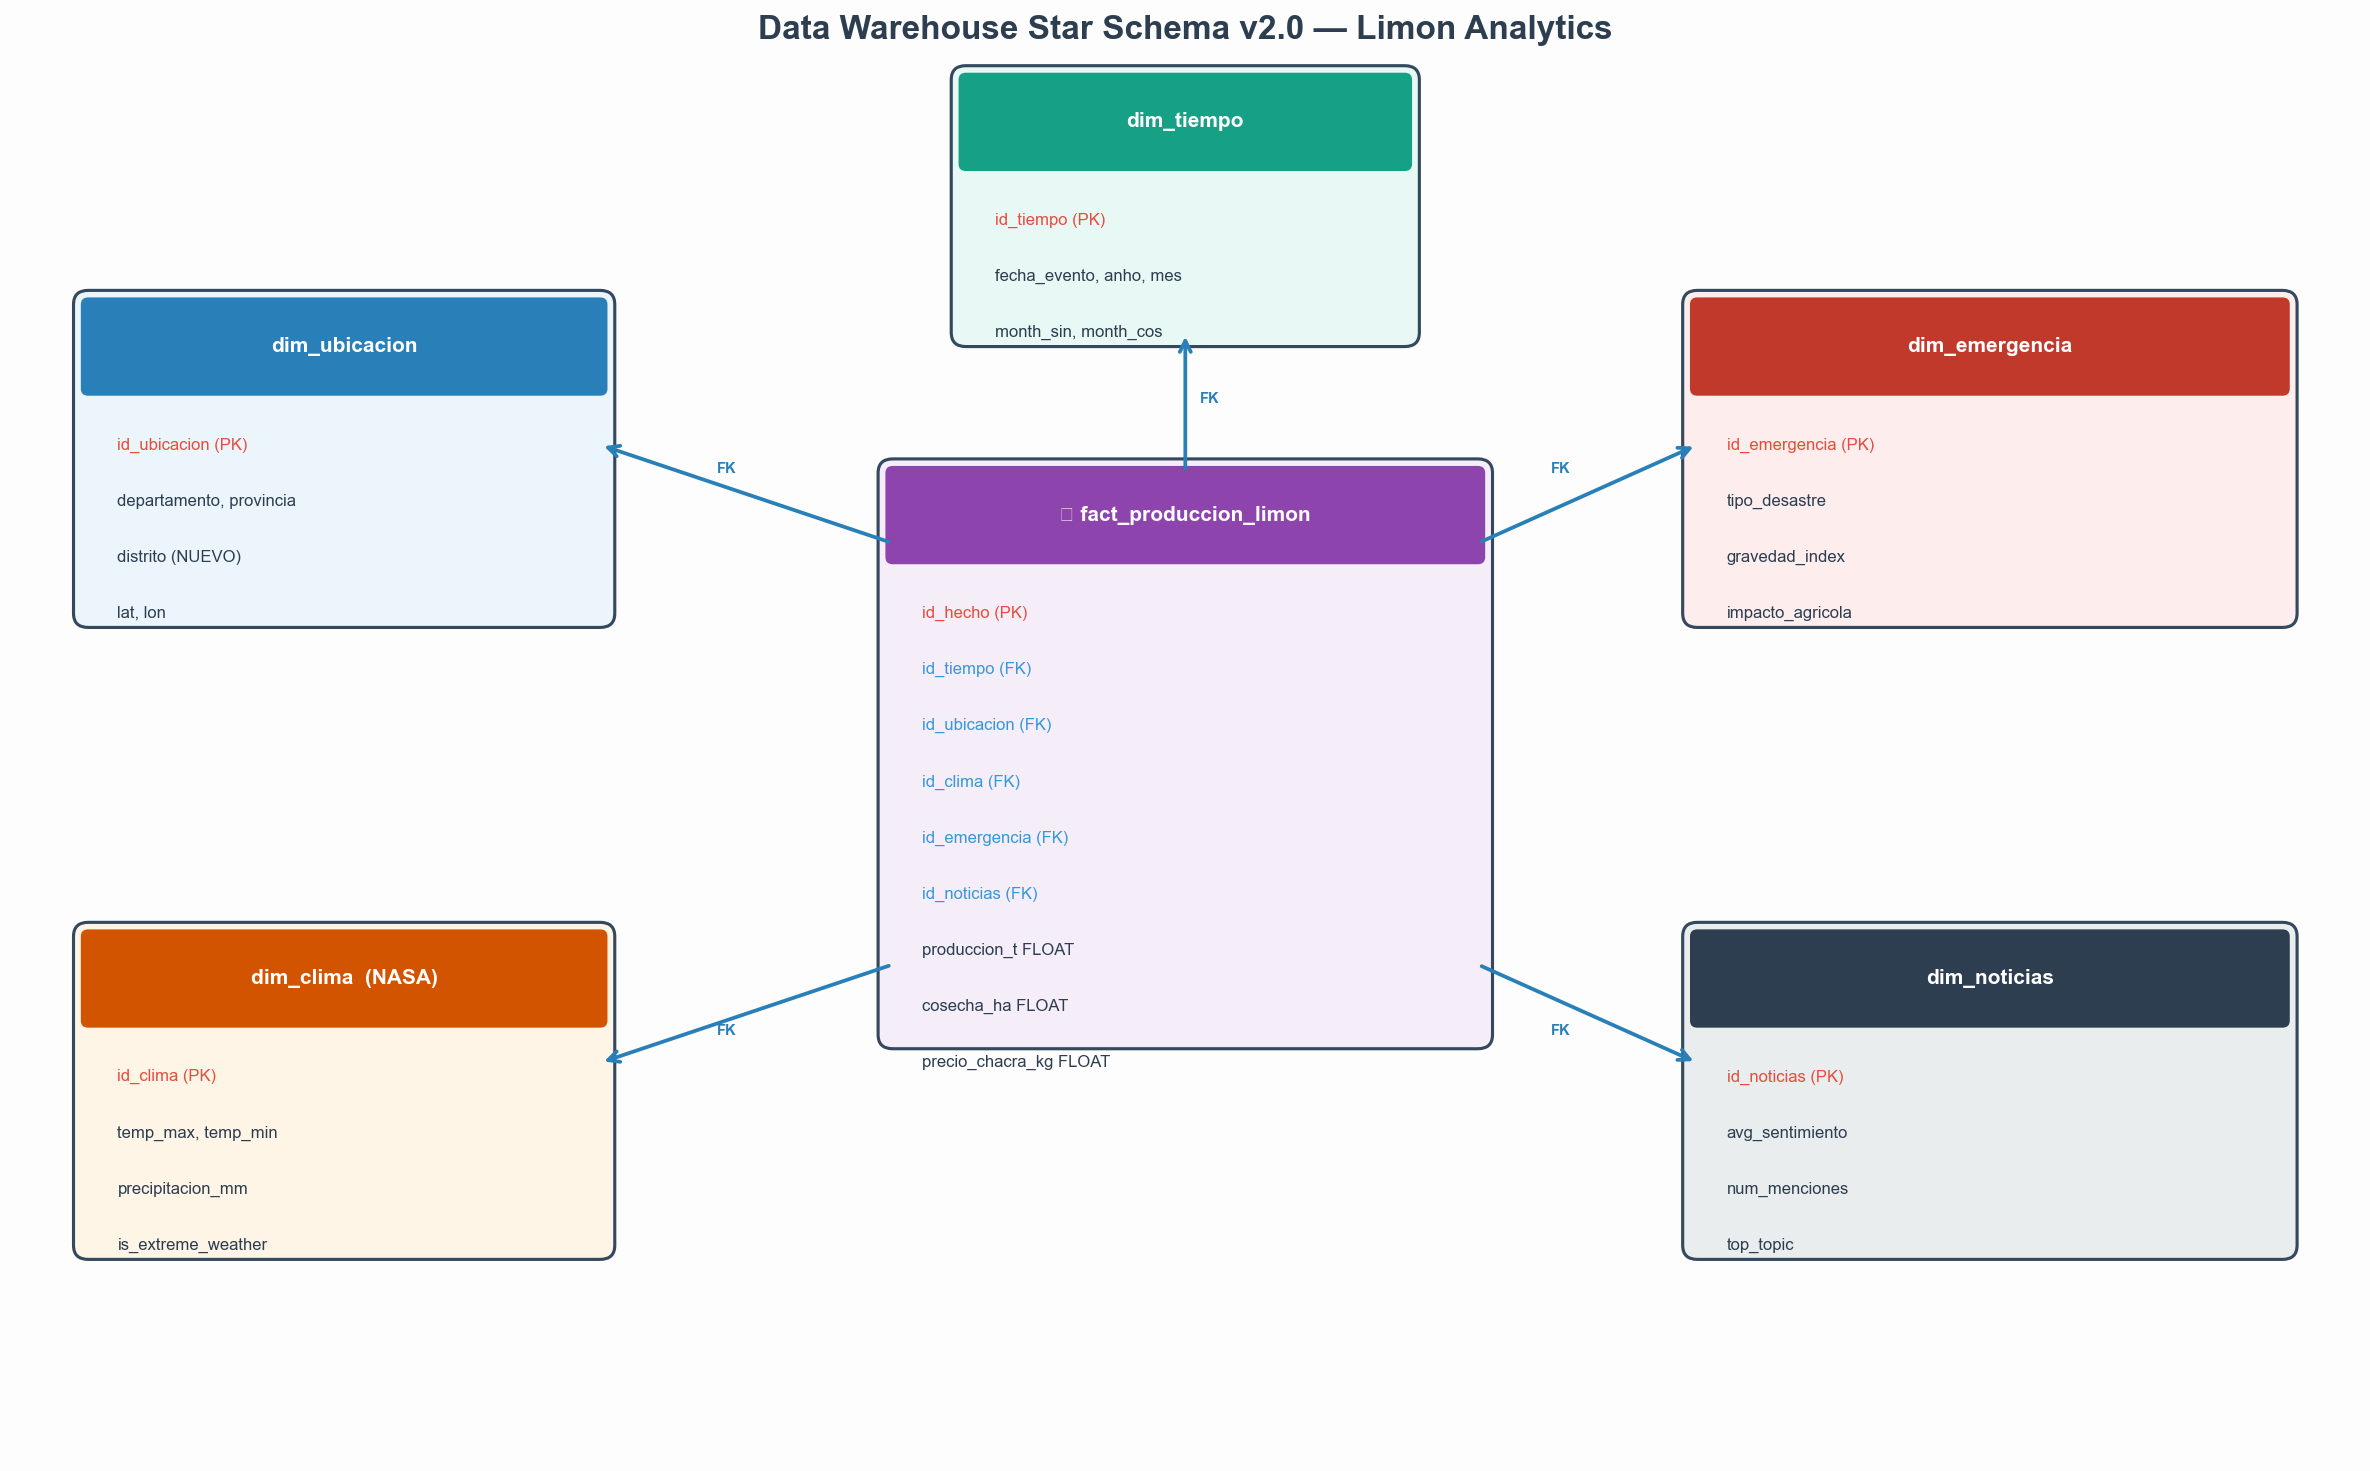
</div>

---

### Vista Técnica (Modelo Dimensional)
```mermaid
erDiagram
    fact_produccion_limon }|--|| dim_tiempo : "FK_Tiempo"
    fact_produccion_limon }|--|| dim_ubicacion : "FK_Ubicacion"
    fact_produccion_limon }|--|| dim_clima : "FK_Clima"
    fact_produccion_limon }|--|| dim_multimodal : "FK_Multimodal"

    dim_tiempo {
        int id_tiempo PK
        varchar fecha_evento "YYYY-MM"
        int anho
        int mes
        float month_sin "Estacionalidad"
        float month_cos "Estacionalidad"
    }

    dim_ubicacion {
        int id_ubicacion PK
        varchar departamento "Región"
        varchar provincia
        float lat
        float lon
    }

    dim_clima {
        int id_clima PK
        float temp_max_c "NASA"
        float temp_min_c "NASA"
        float precipitacion_mm "NASA"
        float radiacion_solar "NASA"
    }

    dim_multimodal {
        int id_multimodal PK
        int n_noticias "NLP"
        int num_emergencias "INDECI"
        float avg_sentimiento "NLP"
        int total_afectados "INDECI"
    }

    fact_produccion_limon {
        int id_hecho PK
        int id_tiempo FK
        int id_ubicacion FK
        int id_clima FK
        int id_multimodal FK
        float produccion_t "Métrica Principal"
        float cosecha_ha
        float precio_chacra_kg "Volatilidad"
    }
```

---

## 7.2 Justificación del Diseño

| Decisión | Justificación |
|:---------|:-------------|
| **Star Schema** (no Snowflake) | Optimiza consultas analíticas con JOINs simples. Ideal para OLAP y alimentar LSTM. |
| **Granularidad mensual** | La producción agrícola se reporta mensualmente. INDECI y noticias se agregan a este nivel. |
| **dim_tiempo con month_sin/cos** | La codificación cíclica captura la estacionalidad biológica del limón sin discontinuidad diciembre→enero. |
| **dim_ubicacion con lat/lon** | Permite futuras integraciones espaciales (NASA POWER por coordenadas). |
| **Columnas NASA como NULL** | Placeholder listo. Las columnas existen en la tabla pero se llenan cuando se integren datos climáticos. |
| **avg_sentimiento como NULL** | Se llenará en Fase 2 cuando se ejecute NLP (BETO/pysentimiento) sobre las noticias. |

---

## 7.3 Relaciones y Cardinalidad

| Relación | Tipo | Descripción |
|:---------|:-----|:------------|
| `fact → dim_tiempo` | N:1 | Muchos registros de producción pueden compartir el mismo mes |
| `fact → dim_ubicacion` | N:1 | Muchos registros de producción pueden compartir la misma provincia |
| **Unicidad** | `(id_tiempo, id_ubicacion)` | Cada combinación mes-provincia tiene exactamente un registro |


In [ ]:

import os, sys, json, warnings
import pandas as pd
from sqlalchemy import create_engine, text
warnings.filterwarnings('ignore')
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(os.path.abspath('..'))
with open('data/02_interim/pipeline_config.json','r',encoding='utf-8') as f:
    CFG = json.load(f)
DIRS=CFG['DIRS']; INTERIM=DIRS['interim']; PG_URI=CFG['PG_URI']
print(f"CWD: {os.getcwd()} | Config OK")


## 7.4 Generación del Script DDL

In [ ]:

DDL = '''-- =================================================================
-- STAR SCHEMA: limon_analytics_db
-- Tesis: Predicción de Producción de Limón — LSTM Multimodal
-- Generado por: Pipeline Fase 1 — Actividad 7
-- =================================================================

CREATE TABLE IF NOT EXISTS dim_tiempo (
    id_tiempo     SERIAL PRIMARY KEY,
    fecha_evento  VARCHAR(7)  NOT NULL UNIQUE,
    anho          SMALLINT    NOT NULL,
    mes           SMALLINT    NOT NULL,
    trimestre     SMALLINT,
    month_sin     FLOAT,
    month_cos     FLOAT
);

CREATE TABLE IF NOT EXISTS dim_ubicacion (
    id_ubicacion  SERIAL PRIMARY KEY,
    departamento  VARCHAR(60) NOT NULL,
    provincia     VARCHAR(60) NOT NULL,
    lat           FLOAT,
    lon           FLOAT,
    UNIQUE (departamento, provincia)
);

CREATE TABLE IF NOT EXISTS dim_clima (
    id_clima          SERIAL PRIMARY KEY,
    temp_max_c        FLOAT,
    temp_min_c        FLOAT,
    precipitacion_mm  FLOAT,
    humedad_rel_pct   FLOAT,
    radiacion_solar   FLOAT
);

CREATE TABLE IF NOT EXISTS dim_multimodal (
    id_multimodal   SERIAL PRIMARY KEY,
    n_noticias      INT DEFAULT 0,
    num_emergencias INT DEFAULT 0,
    total_afectados INT DEFAULT 0,
    avg_sentimiento FLOAT
);

CREATE TABLE IF NOT EXISTS fact_produccion_limon (
    id_hecho              SERIAL PRIMARY KEY,
    id_tiempo             INT NOT NULL REFERENCES dim_tiempo(id_tiempo),
    id_ubicacion          INT NOT NULL REFERENCES dim_ubicacion(id_ubicacion),
    id_clima              INT REFERENCES dim_clima(id_clima),
    id_multimodal         INT REFERENCES dim_multimodal(id_multimodal),
    produccion_t          FLOAT DEFAULT 0,
    cosecha_ha            FLOAT DEFAULT 0,
    precio_chacra_kg      FLOAT,
    UNIQUE (id_tiempo, id_ubicacion)
);

CREATE INDEX IF NOT EXISTS idx_fact_tiempo    ON fact_produccion_limon(id_tiempo);
CREATE INDEX IF NOT EXISTS idx_fact_ubicacion ON fact_produccion_limon(id_ubicacion);
'''

sql_path = f"{DIRS['database']}/dwh_star_schema.sql"
with open(sql_path, 'w', encoding='utf-8') as f:
    f.write(DDL)
print(f"[OK] DDL guardado: {sql_path}")
print("\nContenido del DDL:")
print(DDL)
print("[ACTIVIDAD 07] COMPLETADA.")


## TODO: INTEGRACIÓN DATA NASA (COMPAÑERO)

Cuando integres datos NASA, las columnas ya están reservadas en `fact_produccion_limon`:

| Columna en fact | Variable NASA POWER | Unidad |
|:---------------|:-------------------|:-------|
| `temp_max_c` | T2M_MAX | °C |
| `temp_min_c` | T2M_MIN | °C |
| `precipitacion_mm` | PRECTOTCORR | mm/día |
| `humedad_rel_pct` | RH2M | % |
| `velocidad_viento` | WS2M | m/s |
| `radiacion_solar` | ALLSKY_SFC_SW_DWN | kW-hr/m²/day |

Solo necesitas hacer `UPDATE` o reinsertar con los valores.
